# Assignment 2: Continuous Music Generation without Input

This Jupyter Notebook will train a model to generate music notes. Our dataset will be the NSynth Validation set of Acoustic Guitar notes and our model will be a variational autoencoder (VAE).

**Step 1:** Install Dependencies and import statements

In [2]:
# !pip install librosa 
# !pip install soundfile 
# !pip install numpy 
# !pip install pandas 
# !pip install tqdm 
# !pip install torch
import json
import random
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

**Step 2:** Define global variables used later. These will be used for defining the sampling rate for generating spectrograms, paths for finding data, etc.

In [3]:
RAW_ROOT = Path("data/guitar_acoustic/raw")
AUDIO_DIR = RAW_ROOT
JSON_PATH = RAW_ROOT / "examples_guitar.json"

OUT_ROOT = Path("data/guitar_acoustic/processed")
SPEC_DIR = OUT_ROOT / "specs"
SPEC_DIR.mkdir(parents=True, exist_ok=True)

SR = 16000
CLIP_SECONDS = 2
TARGET_SAMPLES = SR * CLIP_SECONDS

N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 64
TARGET_FRAMES = 128

MAX_EXAMPLES = 2000 

random.seed(0)


**Step 3:** Load in audio and process metadata


These are acoustic guitar audio clips taken from the public nsynth dataset. They are loaded in, along with their metadata

In [4]:
with open(JSON_PATH) as f:
    examples = json.load(f)

rows = []
for note_str, ex in examples.items():
    wav_path = AUDIO_DIR / f"{note_str}.wav"
    if wav_path.exists():
        rows.append({
            "note_str": note_str,
            "wav_path": str(wav_path),
            "pitch": ex["pitch"],
            "velocity": ex["velocity"],
            "instrument_family_str": ex["instrument_family_str"],
            "instrument_source_str": ex["instrument_source_str"],
            "instrument_str": ex["instrument_str"],
        })

print(f"Found {len(rows)} audio clips")

random.shuffle(rows)
rows = rows[:MAX_EXAMPLES]

Found 1482 audio clips


**Step 4:** Generate Mel Spectrograms

For this assignment, we use Mel spectrograms. This is because it provides a way of storing and manipulating audio data in a way that is far more efficient than raw waveforms. In addition, it organizes frequency data logarithmically, mimicking how humans percieve sound, and fit into convolutional models more easily.

These preprocessing parameters were chosen to make the audio representation small enough for CPU training while preserving the main perceptual features of each guitar note. We downsample each clip to 16 kHz and use the first 2 seconds, which captures the attack and decay of most NSynth acoustic guitar notes while avoiding unnecessary silence. The mel spectrogram uses a 1024-sample FFT window, 256-sample hop length, and 64 mel bins, giving a compact time-frequency representation that can be modeled like an image by a convolutional VAE. We fix each spectrogram to 128 time frames so every training example has the same tensor shape.

In [ ]:
processed_rows = []

for row in tqdm(rows):
    wav_path = row["wav_path"]
    note_str = row["note_str"]

    # Load mono audio at 16 kHz.
    y, sr = librosa.load(wav_path, sr=SR, mono=True)

    # Use first 2 seconds. Pad if needed.
    if len(y) < TARGET_SAMPLES:
        y = np.pad(y, (0, TARGET_SAMPLES - len(y)))
    else:
        y = y[:TARGET_SAMPLES]

    # Mel spectrogram, power scale.
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )

    # Convert to dB. Values are roughly [-80, 0].
    mel_db = librosa.power_to_db(mel, ref=np.max, top_db=80.0)

    # Force fixed time dimension.
    mel_db = librosa.util.fix_length(mel_db, size=TARGET_FRAMES, axis=1)

    # Normalize from [-80, 0] to [-1, 1].
    mel_norm = (mel_db + 40.0) / 40.0
    mel_norm = np.clip(mel_norm, -1.0, 1.0)

    # Shape: [1, 64, 128]
    tensor = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0)

    out_path = SPEC_DIR / f"{note_str}.pt"
    torch.save(tensor, out_path)

    row["spec_path"] = str(out_path)
    processed_rows.append(row)

manifest = pd.DataFrame(processed_rows)
manifest.to_csv(OUT_ROOT / "manifest.csv", index=False)

config = {
    "sr": SR,
    "clip_seconds": CLIP_SECONDS,
    "target_samples": TARGET_SAMPLES,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "n_mels": N_MELS,
    "target_frames": TARGET_FRAMES,
    "normalization": "mel_db clipped to [-80, 0], then scaled to [-1, 1]",
    "max_examples": MAX_EXAMPLES,
}

with open(OUT_ROOT / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved manifest to:", OUT_ROOT / "manifest.csv")
print("Saved specs to:", SPEC_DIR)

  0%|          | 0/1482 [00:00<?, ?it/s]

100%|██████████| 1482/1482 [02:28<00:00,  9.97it/s]


Saved manifest to: data/guitar_acoustic/processed/manifest.csv
Saved specs to: data/guitar_acoustic/processed/specs


**Step 5:** Create Dataloaders

We define important variables for training, such as batch size and number of epochs. We also create the dataloaders to feed into our model later for training. We use 85% of our data for training and the rest for testing.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
from pathlib import Path
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

# Paths / constants
MANIFEST_PATH = Path("data/guitar_acoustic/processed/manifest.csv")
SAMPLE_DIR = Path("outputs/vae_samples")
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
LATENT_DIM = 64
EPOCHS = 30
LR = 1e-3
BETA = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MelSpecDataset(Dataset):
    def __init__(self, manifest_path):
        self.df = pd.read_csv(manifest_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = torch.load(row["spec_path"])
        return spec, row["note_str"]

dataset = MelSpecDataset(MANIFEST_PATH)

train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(val_ds)

(1259, 223)

**Step 6:** Define and train VAE


The VAE consists of an encoder and a decoder. The encoder compresses the mel spectrogram from a 1x64x128 representation to a 256x4x8 representation through a series of convolutional layers. This is then parameterized by a mean and a variance, which are used to reconstruct the original spectrogram using a decoder (which also consists of a series of convolutional layers). 

The model balances between optimizing the KL-loss and the reconstruction loss, allowing for a balance between modeling the entire encoding space and accurately reconstructing spectrograms. The model trains for a total of 30 epochs with a batch size of 32.

Epoch 001 | train loss 1.0909 | val loss 0.1133 | train recon 0.2420 | val recon 0.1045 | KL 8.8529
Epoch 002 | train loss 0.1050 | val loss 0.0842 | train recon 0.0947 | val recon 0.0789 | KL 5.3050
Epoch 003 | train loss 0.0868 | val loss 0.0898 | train recon 0.0728 | val recon 0.0856 | KL 4.2021
Epoch 004 | train loss 0.0693 | val loss 0.0695 | train recon 0.0641 | val recon 0.0646 | KL 4.8680
Epoch 005 | train loss 0.0663 | val loss 0.0668 | train recon 0.0613 | val recon 0.0624 | KL 4.4115
Epoch 006 | train loss 0.0573 | val loss 0.0546 | train recon 0.0528 | val recon 0.0498 | KL 4.7629
Epoch 007 | train loss 0.0500 | val loss 0.0518 | train recon 0.0460 | val recon 0.0473 | KL 4.5354
Epoch 008 | train loss 0.0436 | val loss 0.0463 | train recon 0.0390 | val recon 0.0403 | KL 5.9889
Epoch 009 | train loss 0.0397 | val loss 0.0358 | train recon 0.0347 | val recon 0.0310 | KL 4.7960
Epoch 010 | train loss 0.0367 | val loss 0.0448 | train recon 0.0312 | val recon 0.0354 | KL 9.3970


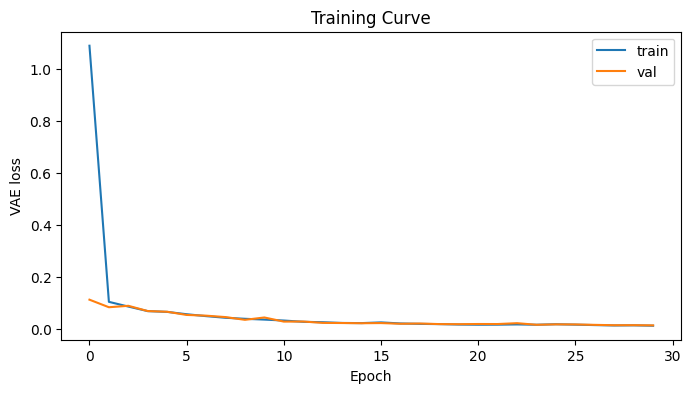

In [9]:


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # Input: [B, 1, 64, 128]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # [B, 32, 32, 64]
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # [B, 64, 16, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # [B, 128, 8, 16]
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # [B, 256, 4, 8]
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 4 * 8

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # [B, 128, 8, 16]
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # [B, 64, 16, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # [B, 32, 32, 64]
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),    # [B, 1, 64, 128]
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon, x, mu, logvar, beta=0.001):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_recon": [],
    "val_recon": [],
    "train_kl": [],
    "val_kl": [],
}

for epoch in range(EPOCHS):
    model.train()

    train_loss = train_recon = train_kl = 0.0

    for specs, _ in train_loader:
        specs = specs.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(specs)
        loss, recon_loss, kl_loss = vae_loss(recon, specs, mu, logvar, beta=BETA)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    train_loss /= len(train_loader)
    train_recon /= len(train_loader)
    train_kl /= len(train_loader)

    model.eval()
    val_loss = val_recon = val_kl = 0.0

    with torch.no_grad():
        for specs, _ in val_loader:
            specs = specs.to(device)
            recon, mu, logvar = model(specs)
            loss, recon_loss, kl_loss = vae_loss(recon, specs, mu, logvar, beta=BETA)

            val_loss += loss.item()
            val_recon += recon_loss.item()
            val_kl += kl_loss.item()

    val_loss /= len(val_loader)
    val_recon /= len(val_loader)
    val_kl /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_recon"].append(train_recon)
    history["val_recon"].append(val_recon)
    history["train_kl"].append(train_kl)
    history["val_kl"].append(val_kl)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
        f"train recon {train_recon:.4f} | val recon {val_recon:.4f} | "
        f"KL {val_kl:.4f}"
    )

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.legend()
plt.title("Training Curve")
plt.show()

**Step 7:** Produce outputs

Here, we first try to reconstruct a single spectrogram accurately to see if the encoder and decoder work together properly. Then, we generate random vectors in the encoding space and send them through the decoder, allowing us to generate entirely new audio clips from scratch. Finally, we convert these spectrograms back to audio clips and save them.

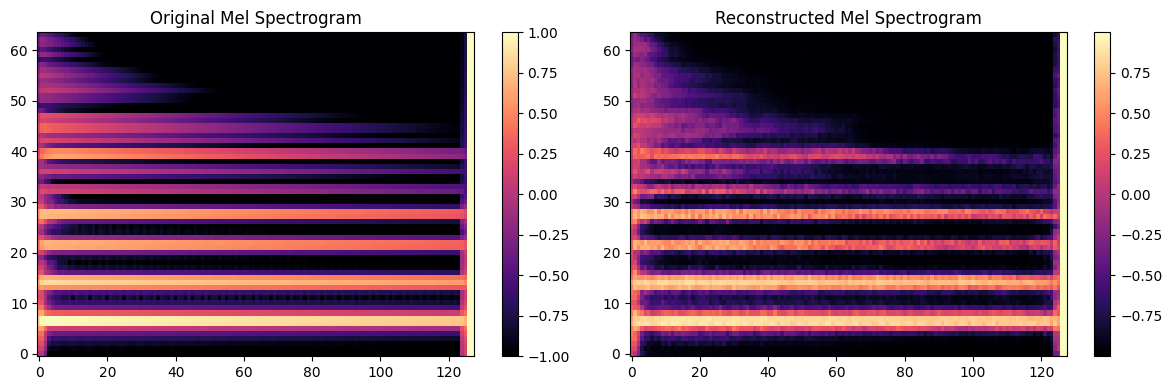

Saved generated clips to outputs/vae_samples


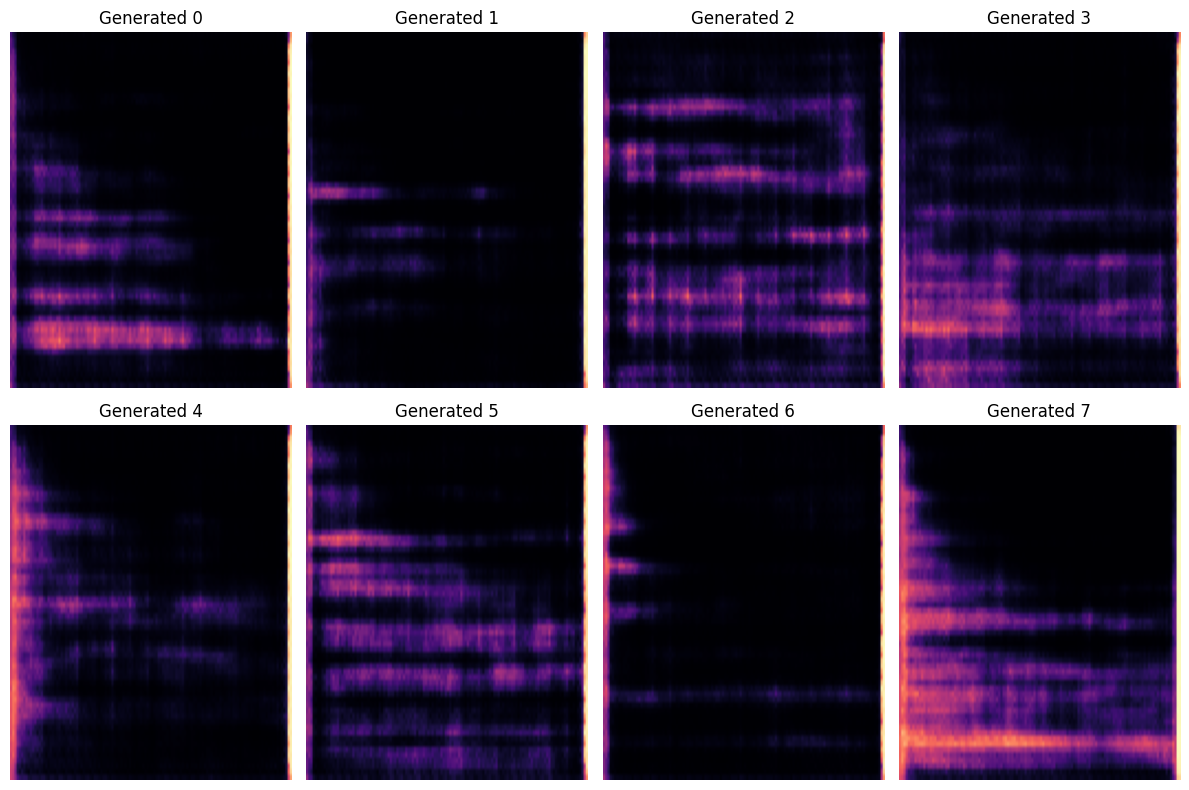

In [13]:
def denormalize_mel(mel_norm):
    # Inverse of: mel_norm = (mel_db + 40) / 40
    return mel_norm * 40.0 - 40.0


def mel_norm_to_audio(mel_norm, out_path=None):
    """
    mel_norm shape: [64, 128], values in [-1, 1]
    """
    mel_db = denormalize_mel(mel_norm)
    mel_power = librosa.db_to_power(mel_db)

    audio = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_iter=64,
        power=2.0,
    )

    if out_path is not None:
        sf.write(out_path, audio, SR)

    return audio

model.eval()

specs, names = next(iter(val_loader))
specs = specs.to(device)

with torch.no_grad():
    recon, mu, logvar = model(specs)

# Take first example
original = specs[0, 0].cpu().numpy()
reconstructed = recon[0, 0].cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, origin="lower", aspect="auto", cmap="magma")
plt.title("Original Mel Spectrogram")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, origin="lower", aspect="auto", cmap="magma")
plt.title("Reconstructed Mel Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

# Save original-ish audio from original mel and reconstructed audio
mel_norm_to_audio(original, SAMPLE_DIR / "reconstruction_original_mel.wav")
mel_norm_to_audio(reconstructed, SAMPLE_DIR / "reconstruction_vae.wav")

model.eval()

num_samples = 8

with torch.no_grad():
    z = torch.randn(num_samples, LATENT_DIM).to(device)
    generated = model.decode(z).cpu()

for i in range(num_samples):
    mel_norm = generated[i, 0].numpy()
    out_path = SAMPLE_DIR / f"generated_{i:02d}.wav"
    mel_norm_to_audio(mel_norm, out_path)

print(f"Saved generated clips to {SAMPLE_DIR}")

# Visualize generated spectrograms
plt.figure(figsize=(12, 8))

for i in range(min(num_samples, 8)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(generated[i, 0].numpy(), origin="lower", aspect="auto", cmap="magma")
    plt.title(f"Generated {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "latent_dim": LATENT_DIM,
        "history": history,
    },
    "outputs/vae_guitar_mel.pt",
)